## The code to train ResNet50 classifier and U-Net model for Segmentation can be found below. Each cell of the code has a brief explanation of what its usage.

Worked by : Gleris Xhoxha

Importing the libraries

In [4]:
import os
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

DOWNLOAD AND EXTRACT OXFORD 17 FLOWERS DATASET

In [5]:
!wget -q https://www.robots.ox.ac.uk/~vgg/data/flowers/17/17flowers.tgz
!wget -q https://www.robots.ox.ac.uk/~vgg/data/flowers/17/trimaps.tgz

!mkdir -p /content/flowers17
!tar -xzf 17flowers.tgz -C /content/flowers17
!tar -xzf trimaps.tgz -C /content/flowers17

print(os.listdir("/content/flowers17"))

['jpg', 'trimaps']


CREATE DATAFRAME AND MATCH IMAGES WITH SEGMENTATION MASKS

In [18]:
# ============================================================
# FIXED DATAFRAME FOR 17 FLOWERS + MASKS
# ============================================================

image_dir = "/content/flowers17/jpg"
mask_dir = "/content/flowers17/trimaps"

image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith(".jpg")
])

mask_files = sorted([
    f for f in os.listdir(mask_dir)
    if f.lower().endswith(".png")
])

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

data = []

for i, img_name in enumerate(image_files):
    class_id = i // 80

    if class_id >= 17:
        continue

    class_name = f"class_{class_id}"

    img_path = os.path.join(image_dir, img_name)

    # Try both possible mask names
    mask_name_1 = img_name.replace(".jpg", ".png")                # image_0001.png
    mask_name_2 = img_name.replace("image_", "trimap_").replace(".jpg", ".png")  # trimap_0001.png

    mask_path_1 = os.path.join(mask_dir, mask_name_1)
    mask_path_2 = os.path.join(mask_dir, mask_name_2)

    if os.path.exists(mask_path_1):
        mask_path = mask_path_1
    elif os.path.exists(mask_path_2):
        mask_path = mask_path_2
    else:
        continue

    data.append([img_path, mask_path, class_name])

df = pd.DataFrame(data, columns=["image_path", "mask_path", "class_name"])

print(df.head())
print("Total matched image-mask pairs:", len(df))
print("Total classes:", df["class_name"].nunique())
print(df["class_name"].value_counts().sort_index())

Number of images: 1360
Number of masks: 848
                              image_path  \
0  /content/flowers17/jpg/image_0001.jpg   
1  /content/flowers17/jpg/image_0002.jpg   
2  /content/flowers17/jpg/image_0003.jpg   
3  /content/flowers17/jpg/image_0004.jpg   
4  /content/flowers17/jpg/image_0005.jpg   

                                   mask_path class_name  
0  /content/flowers17/trimaps/image_0001.png    class_0  
1  /content/flowers17/trimaps/image_0002.png    class_0  
2  /content/flowers17/trimaps/image_0003.png    class_0  
3  /content/flowers17/trimaps/image_0004.png    class_0  
4  /content/flowers17/trimaps/image_0005.png    class_0  
Total matched image-mask pairs: 848
Total classes: 16
class_name
class_0     71
class_1     50
class_10    57
class_11    43
class_12    55
class_14    54
class_15    63
class_16    56
class_2     17
class_3     28
class_4     50
class_5     78
class_6     49
class_7     41
class_8     65
class_9     71
Name: count, dtype: int64


 SPLIT DATASET INTO TRAINING AND VALIDATION SETS

In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["class_name"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 1088
Validation: 272


**IMAGE PREPROCESSING, DATA AUGMENTATION AND DATA GENERATOR CONFIGURATION FOR TRAINING AND VALIDATION DATASETS**

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.15,
    rotation_range=10
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="class_name",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="class_name",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)

print("Number of classes:", NUM_CLASSES)
print(train_gen.class_indices)

Found 1088 validated image filenames belonging to 17 classes.
Found 272 validated image filenames belonging to 17 classes.
Number of classes: 17
{'class_0': 0, 'class_1': 1, 'class_10': 2, 'class_11': 3, 'class_12': 4, 'class_13': 5, 'class_14': 6, 'class_15': 7, 'class_16': 8, 'class_2': 9, 'class_3': 10, 'class_4': 11, 'class_5': 12, 'class_6': 13, 'class_7': 14, 'class_8': 15, 'class_9': 16}


# Classification using  the ResNet50 Model

In [12]:
# ============================================================
# 6. RESNET50 CLASSIFICATION MODEL
# ============================================================

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in resnet_base.layers:
    layer.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

resnet_model = Model(inputs=resnet_base.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,116,625 (92.00 MB)

 Trainable params: 528,913 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 ResNet50 is a deep CNN that introduces residual learning through skip connections, allowing the network to train effectively even with a large
 number of layers.

 In this project, transfer learning is used by leveraging weights pre-trained on the ImageNet dataset.

  Model Architecture:
 1. Pre-trained ResNet50 feature extractor
 2. Global Average Pooling layer
 3. Fully Connected Dense layer (256 neurons)
 4. Dropout layer for regularization
 5. Softmax output layer for multi-class classification

 The model is optimized using the Adam optimizer and trained
 using categorical cross-entropy loss.

In [13]:
# ============================================================
# 7. TRAIN RESNET50
# ============================================================

EPOCHS = 10

history = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 39s 713ms/step - accuracy: 0.1480 - loss: 2.9050 - val_accuracy: 0.4816 - val_loss: 1.9807
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 485ms/step - accuracy: 0.4182 - loss: 1.9038 - val_accuracy: 0.7206 - val_loss: 1.3451
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 481ms/step - accuracy: 0.6305 - loss: 1.3089 - val_accuracy: 0.8272 - val_loss: 0.9581
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 469ms/step - accuracy: 0.7279 - loss: 1.0379 - val_accuracy: 0.8235 - val_loss: 0.7598
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 460ms/step - accuracy: 0.7757 - loss: 0.8205 - val_accuracy: 0.8603 - val_loss: 0.6114
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 462ms/step - accuracy: 0.8346 - loss: 0.6540 - val_accuracy: 0.8860 - val_loss: 0.5206
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 494ms/step - accuracy: 0.8575 - loss: 0.5614 - val_accuracy: 0.8860 - val_loss: 0.4664
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 463ms/step - accuracy: 0.8704 - loss: 0.4889 - val_accu

During this phase, the ResNet50 model is trained using the
prepared training dataset and evaluated on the validation dataset after each epoch.

The training process runs for 10 epochs.

We chose 10 epochs since it was a bit hard to train for more epochs on limited GPU.

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.9228 - loss: 0.3417
Validation Accuracy: 92.28 %
Validation Loss: 0.3417


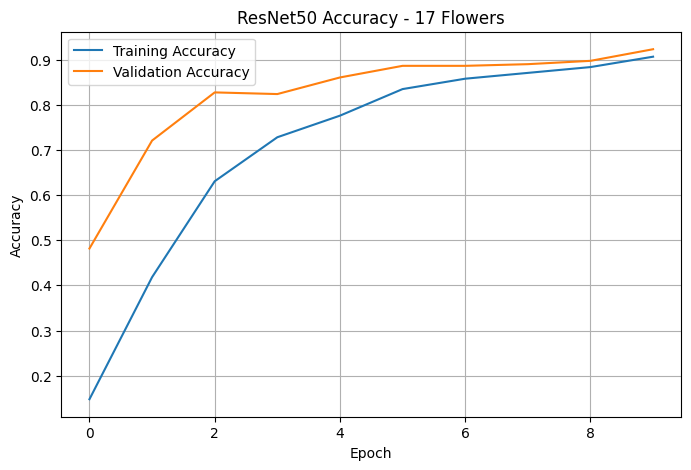

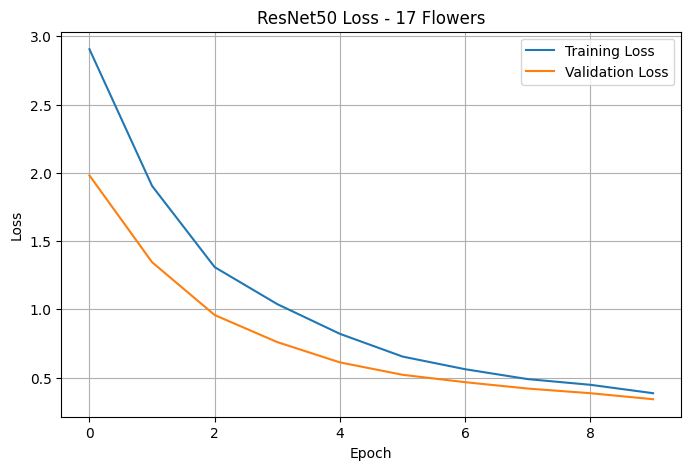

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 550ms/step
Final Validation Accuracy: 92.28 %


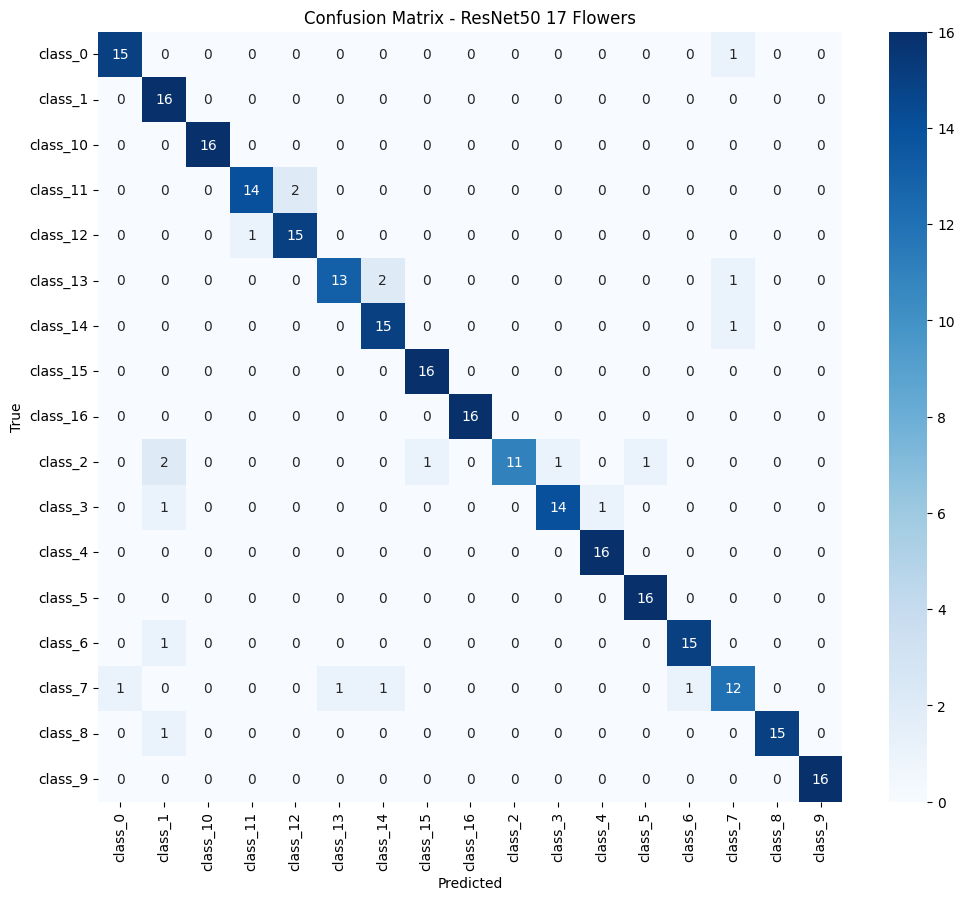

              precision    recall  f1-score   support

     class_0       0.94      0.94      0.94        16
     class_1       0.76      1.00      0.86        16
    class_10       1.00      1.00      1.00        16
    class_11       0.93      0.88      0.90        16
    class_12       0.88      0.94      0.91        16
    class_13       0.93      0.81      0.87        16
    class_14       0.83      0.94      0.88        16
    class_15       0.94      1.00      0.97        16
    class_16       1.00      1.00      1.00        16
     class_2       1.00      0.69      0.81        16
     class_3       0.93      0.88      0.90        16
     class_4       0.94      1.00      0.97        16
     class_5       0.94      1.00      0.97        16
     class_6       0.94      0.94      0.94        16
     class_7       0.80      0.75      0.77        16
     class_8       1.00      0.94      0.97        16
     class_9       1.00      1.00      1.00        16

    accuracy              

In [14]:
val_loss, val_acc = resnet_model.evaluate(val_gen)

print("Validation Accuracy:", round(val_acc * 100, 2), "%")
print("Validation Loss:", round(val_loss, 4))

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("ResNet50 Accuracy - 17 Flowers")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ResNet50 Loss - 17 Flowers")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


val_gen.reset()
predictions = resnet_model.predict(val_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes

class_labels = list(val_gen.class_indices.keys())

acc = accuracy_score(y_true, y_pred)
print("Final Validation Accuracy:", round(acc * 100, 2), "%")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix - ResNet50 17 Flowers")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))

# ============================================================
# 11. SAVE CLASSIFICATION MODEL
# ============================================================

resnet_model.save("/content/resnet50_17flowers.h5")
print("Classification model saved.")

The trained ResNet50 model is evaluated using the validation dataset.

Validation accuracy and loss are computed, while performance curves, confusion matrix, and classification report are generated to analyze the model's effectiveness.

The trained model is then saved for future use.

# Segmentation using U-Net

In [24]:
SEG_SIZE = 128

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (SEG_SIZE, SEG_SIZE))
    img = img / 255.0
    return img

from PIL import Image

def load_mask(path):
    mask = Image.open(path).convert("L")
    mask = np.array(mask)

    mask = cv2.resize(
        mask,
        (SEG_SIZE, SEG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    mask = np.where(mask > 0, 1, 0)

    mask = np.expand_dims(mask, axis=-1)

    return mask.astype(np.float32)

X = np.array([load_image(p) for p in df["image_path"]])
Y = np.array([load_mask(p) for p in df["mask_path"]])

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)

X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

Images shape: (848, 128, 128, 3)
Masks shape: (848, 128, 128, 1)


In this part images and corresponding segmentation masks are loaded, resized to a fixed resolution (128x128), and normalized. Binary masks are generated to distinguish flower regions from the background. The dataset is then split into training and validation sets for model development.

[  0  15  38  75 113]


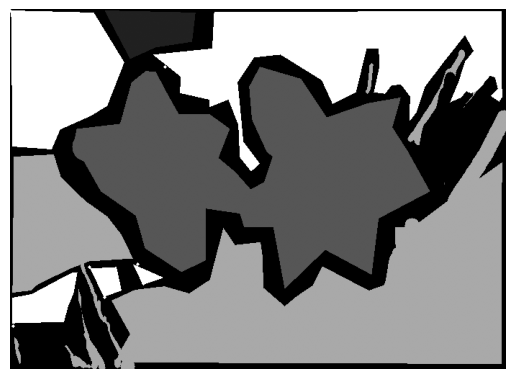

In [25]:
sample_mask = Image.open(df["mask_path"].iloc[0]).convert("L")
sample_mask = np.array(sample_mask)

print(np.unique(sample_mask))

plt.imshow(sample_mask, cmap="gray")
plt.axis("off")
plt.show()

The image upwards is just a mask of a image. We did this in order to check if the masks are being saved correctly.

In [26]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def conv_block(inputs, filters):
    x = Conv2D(filters, 3, padding="same", activation="relu")(inputs)
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def build_unet(input_shape=(128, 128, 3)):
    inputs = Input(input_shape)

    c1 = conv_block(inputs, 32)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = MaxPooling2D()(c3)

    c4 = conv_block(p3, 256)

    u1 = UpSampling2D()(c4)
    u1 = Concatenate()([u1, c3])
    c5 = conv_block(u1, 128)

    u2 = UpSampling2D()(c5)
    u2 = Concatenate()([u2, c2])
    c6 = conv_block(u2, 64)

    u3 = UpSampling2D()(c6)
    u3 = Concatenate()([u3, c1])
    c7 = conv_block(u3, 32)

    outputs = Conv2D(1, 1, activation="sigmoid")(c7)

    return Model(inputs, outputs)

unet_model = build_unet()

unet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

unet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_15[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_17[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_19[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │    590,080 │ conv2d_21[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 32, 32,    │          0 │ conv2d_22[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 384)              │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    442,496 │ concatenate_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_23[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 64, 64,    │          0 │ conv2d_24[0][0] 

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

Build and configure a U-Net architecture for binary image segmentation. The model uses an encoder-decoder structure with skip connections to accurately identify flower regions within the input images.

The encoder captures spatial features through convolution and pooling operations, while the decoder reconstructs the segmentation mask using upsampling and skip connections.

In [27]:
seg_history = unet_model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=10,
    batch_size=16
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 201ms/step - accuracy: 0.7531 - loss: 0.5628 - val_accuracy: 0.8626 - val_loss: 0.4628
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8628 - loss: 0.4256 - val_accuracy: 0.8626 - val_loss: 0.3857
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.8628 - loss: 0.3520 - val_accuracy: 0.8626 - val_loss: 0.3563
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.8628 - loss: 0.3154 - val_accuracy: 0.8627 - val_loss: 0.3080
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.8754 - loss: 0.2919 - val_accuracy: 0.8788 - val_loss: 0.3015
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.8855 - loss: 0.2821 - val_accuracy: 0.8880 - val_loss: 0.2726
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8944 - loss: 0.2620 - val_accuracy: 0.8952 - val_loss: 0.2590
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9012 - loss: 0.2442 - val_accuracy: 0.9002 -

In [29]:
seg_loss, seg_acc = unet_model.evaluate(X_val, Y_val)

print("Segmentation Validation Accuracy:", round(seg_acc * 100, 2), "%")
print("Segmentation Validation Loss:", round(seg_loss, 4))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9098 - loss: 0.2269
Segmentation Validation Accuracy: 90.98 %
Segmentation Validation Loss: 0.2269


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step


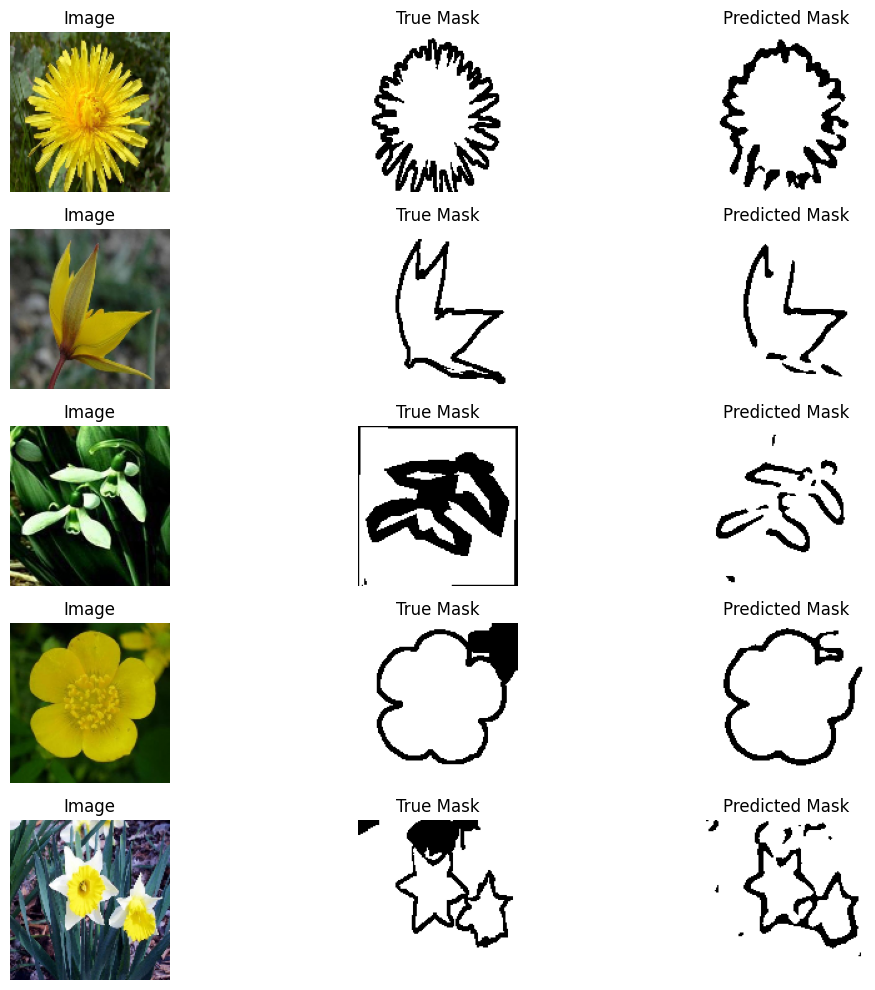

In [28]:
pred_masks = unet_model.predict(X_val[:5])

plt.figure(figsize=(12, 10))

for i in range(5):
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(X_val[i])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(Y_val[i].squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(pred_masks[i].squeeze() > 0.5, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Visualization of Segmentation Results**

Generate segmentation predictions on validation images and compare them with the corresponding ground-truth masks. This visual comparison helps assess the quality of the U-Net model by displaying the original image, true mask, and predicted mask side by side.